# Three-Way Comparison: SynthSeg v1 vs. FastSurfer vs. SynthSeg v2

This notebook compares three whole-brain segmentation approaches on the 20-subject
NKI-TRT-20 (Mindboggle-101) test set, evaluated against manual DKT+aseg ground truth:

- **SynthSeg v1.0** (`--v1`, combined cortex label per hemisphere)
- **FastSurfer** (DKT cortical parcellation, collapsed to combined cortex for this comparison)
- **SynthSeg v2.0** (`--parc`, DKT cortical parcellation, collapsed to combined cortex for this comparison)

All three are evaluated on the same 31-structure collapsed label set (standard FreeSurfer
aseg IDs + combined left/right cerebral cortex, **excluding CSF** - see the note below
on why), so scores are directly comparable.

Individual per-subject evaluation, per-model qualitative grids, and full-resolution
(cortical-parcel-level) results for SynthSeg v2 and FastSurfer live in their own notebooks.
This notebook only combines the already-computed CSVs into the head-to-head comparison.


## A note on structure count, visualization style, and the CSF exclusion

Plotting all 31 collapsed structures individually on one axis (as a boxplot, bar chart,
or line chart) is not legible and is not how comparable neuroimaging papers present this
kind of result. Two standard simplifications are used throughout this notebook, following
the conventions in Billot et al. 2023 (*SynthSeg*, Medical Image Analysis) and Hoffmann et al.
2022 (*SynthMorph*, IEEE TMI):

1. **Bilateral averaging.** Both papers explicitly average left/right homologous structures
   before plotting or tabulating (SynthMorph, Section II-D: *"We average scores of bilateral
   structures"*). The full collapsed label set has 14 bilateral pairs (13 standard aseg pairs
   + 1 cortex pair) and, before any exclusion, 4 midline structures with no hemisphere
   counterpart (3rd ventricle, 4th ventricle, brainstem, CSF) - **14 x 2 + 4 = 32 labels,
   averaging down to 14 + 4 = 18 entities.**
2. **Categorical grouping for headline figures.** SynthMorph Fig. 7 does not plot individual
   anatomical structures - it groups by dataset/contrast pairing on the x-axis, with one
   boxplot cluster per group, colored by method. Our analogue is anatomical category rather
   than contrast: **Ventricular System, Subcortical Gray Nuclei, Cerebral Tissue, Cerebellum,
   Brainstem** (5 groups). This is the headline comparison figure (Figure 1 below).

### Why CSF is excluded from the headline comparison

SynthSeg's label taxonomy does not include a general extraventricular CSF class the way
FreeSurfer's aseg-style output does. This was confirmed directly on this dataset before
excluding anything, rather than assumed:

| Model | Mean CSF Dice | Subjects with any nonzero CSF prediction |
|---|---|---|
| FastSurfer | 0.826 | 20 / 20 |
| SynthSeg v1 | 0.000 | 0 / 20 |
| SynthSeg v2 | 0.006 | 0 / 20 |

SynthSeg does not produce a CSF prediction at all - not occasionally missing it, structurally
never outputting it. Averaging this into an overall Dice score would penalize SynthSeg for a
structure it was never designed to segment, which is not a fair architecture-vs-architecture
comparison. **CSF is therefore excluded from every headline table and figure in this
notebook**, dropping the working set from 32 labels / 18 entities to **31 labels / 17
entities** (14 pairs + 3 remaining midline structures: 3rd ventricle, 4th ventricle,
brainstem).

This exclusion is not hidden: the original 32-label/18-entity numbers, CSF included, are
kept in a supplementary table (Table S0, right after Table 1) for full transparency.

The 17-entity level of detail is not discarded either - it appears in a sorted per-entity
line chart (matching SynthSeg's ablation-study figure style, Fig. 9) and in a supplementary
full box plot and heatmap, for readers who want structure-level detail.

Overall summary statistics (Table 1) follow SynthSeg's Table 2 exactly: mean +/- SD Dice,
HD95, and ASSD per model, with the best score in **bold**, marked with a star if
significantly better than both other models (paired two-sided Wilcoxon signed-rank test,
Bonferroni-corrected across the 3 pairwise comparisons, alpha = 0.05).


In [ ]:
# Cell 1
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q nibabel

import os
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import wilcoxon
from matplotlib.patches import Patch

# ---------------- Paths ----------------
BASE = "/content/drive/MyDrive/Registration"
OUT_DIR = f"{BASE}/Comparison_SynthSeg_v1_v2_FastSurfer"
os.makedirs(OUT_DIR, exist_ok=True)

SYNTHSEG_V2_COMPARISON = f"{BASE}/SynthSeg_v2/evaluation_results/synthseg_v2_for_comparison.csv"
SYNTHSEG_V1_RAW        = f"{BASE}/Mindboggle_SynthSeg/evaluation_results/synthseg_per_structure_raw.csv"
FASTSURFER_COMPARISON  = f"{BASE}/Mindboggle_FastSurfer/evaluation_results/fastsurfer_for_comparison.csv"

# ---------------- Journal-style plotting defaults ----------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Colorblind-safe palette (Okabe-Ito), consistent across every figure in this notebook
MODEL_COLORS = {
    "FastSurfer":   "#D55E00",   # vermillion
    "SynthSeg_v1":  "#009E73",   # bluish green
    "SynthSeg_v2":  "#0072B2",   # blue
}
MODEL_ORDER = ["FastSurfer", "SynthSeg_v1", "SynthSeg_v2"]

print("Setup complete.")


Setup complete.


In [ ]:
# ---------------- Load and standardize all three sources ----------------

v2 = pd.read_csv(SYNTHSEG_V2_COMPARISON)
fs = pd.read_csv(FASTSURFER_COMPARISON)
v1_raw = pd.read_csv(SYNTHSEG_V1_RAW)

# v1's raw CSV was never tagged with a 'model' column or run through the collapse step -
# but SynthSeg v1 (no --parc) already outputs one combined cortex label per hemisphere
# natively, so its raw per-structure output already matches the 32-structure collapsed
# convention used by v2 and FastSurfer. We only need to add the model tag.
v1 = v1_raw.copy()
v1['model'] = 'SynthSeg_v1'

# Sanity check: all three should reference the same structure name set before concatenating
sets = {'FastSurfer': set(fs['structure'].unique()),
        'SynthSeg_v1': set(v1['structure'].unique()),
        'SynthSeg_v2': set(v2['structure'].unique())}
common = set.intersection(*sets.values())
print("Structures common to all three:", len(common))
for name, s in sets.items():
    extra = s - common
    if extra:
        print(f"  {name} has structures not shared by all three:", sorted(extra))

all_data_with_csf = pd.concat([fs, v1, v2], ignore_index=True)
all_data_with_csf = all_data_with_csf[all_data_with_csf['structure'].isin(common)].copy()

# CSF is excluded from every headline table/figure from here on - see the rationale above.
# all_data_with_csf (32 labels) is kept only for the Table S0 supplementary comparison.
N_CSF_ROWS = (all_data_with_csf['structure'] == 'CSF').sum()
print(f"Excluding {N_CSF_ROWS} CSF rows from the headline comparison (kept in all_data_with_csf for Table S0)")
all_data = all_data_with_csf[all_data_with_csf['structure'] != 'CSF'].copy()
print("\nTotal rows:", len(all_data), "| Models:", all_data['model'].unique().tolist())
print("Subjects per model:", all_data.groupby('model')['subject'].nunique().to_dict())

Structures common to all three: 32
Excluding 60 CSF rows from the headline comparison (kept in all_data_with_csf for Table S0)

Total rows: 1860 | Models: ['FastSurfer', 'SynthSeg_v1', 'SynthSeg_v2']
Subjects per model: {'FastSurfer': 20, 'SynthSeg_v1': 20, 'SynthSeg_v2': 20}


## Bilateral averaging and anatomical categorization

Structure names follow the `Left-X` / `Right-X` convention (plus the collapsed
`Left-Cerebral-Cortex` / `Right-Cerebral-Cortex`). We average each subject's Dice/HD95/ASSD
across hemispheres to get one value per **entity** per subject per model, then assign each
entity to one of 5 anatomical categories.


In [ ]:
# ---------------- Bilateral pairing ----------------

BILATERAL_MAP = {
    'Left-Cerebral-White-Matter': 'Cerebral-White-Matter', 'Right-Cerebral-White-Matter': 'Cerebral-White-Matter',
    'Left-Lateral-Ventricle': 'Lateral-Ventricle', 'Right-Lateral-Ventricle': 'Lateral-Ventricle',
    'Left-Inf-Lat-Vent': 'Inf-Lat-Vent', 'Right-Inf-Lat-Vent': 'Inf-Lat-Vent',
    'Left-Cerebellum-White-Matter': 'Cerebellum-White-Matter', 'Right-Cerebellum-White-Matter': 'Cerebellum-White-Matter',
    'Left-Cerebellum-Cortex': 'Cerebellum-Cortex', 'Right-Cerebellum-Cortex': 'Cerebellum-Cortex',
    'Left-Thalamus': 'Thalamus', 'Right-Thalamus': 'Thalamus',
    'Left-Caudate': 'Caudate', 'Right-Caudate': 'Caudate',
    'Left-Putamen': 'Putamen', 'Right-Putamen': 'Putamen',
    'Left-Pallidum': 'Pallidum', 'Right-Pallidum': 'Pallidum',
    'Left-Hippocampus': 'Hippocampus', 'Right-Hippocampus': 'Hippocampus',
    'Left-Amygdala': 'Amygdala', 'Right-Amygdala': 'Amygdala',
    'Left-Accumbens-area': 'Accumbens-area', 'Right-Accumbens-area': 'Accumbens-area',
    'Left-VentralDC': 'VentralDC', 'Right-VentralDC': 'VentralDC',
    'Left-Cerebral-Cortex': 'Cerebral-Cortex', 'Right-Cerebral-Cortex': 'Cerebral-Cortex',
    # Midline / unpaired structures pass through unchanged
    '3rd-Ventricle': '3rd-Ventricle', '4th-Ventricle': '4th-Ventricle',
    'Brain-Stem': 'Brain-Stem', 'CSF': 'CSF',
}

CATEGORY_MAP = {
    'Lateral-Ventricle': 'Ventricular System', 'Inf-Lat-Vent': 'Ventricular System',
    '3rd-Ventricle': 'Ventricular System', '4th-Ventricle': 'Ventricular System', 'CSF': 'Ventricular System',
    'Thalamus': 'Subcortical Gray Nuclei', 'Caudate': 'Subcortical Gray Nuclei',
    'Putamen': 'Subcortical Gray Nuclei', 'Pallidum': 'Subcortical Gray Nuclei',
    'Accumbens-area': 'Subcortical Gray Nuclei', 'Amygdala': 'Subcortical Gray Nuclei',
    'Hippocampus': 'Subcortical Gray Nuclei', 'VentralDC': 'Subcortical Gray Nuclei',
    'Cerebellum-White-Matter': 'Cerebellum', 'Cerebellum-Cortex': 'Cerebellum',
    'Cerebral-White-Matter': 'Cerebral Tissue', 'Cerebral-Cortex': 'Cerebral Tissue',
    'Brain-Stem': 'Brainstem',
}

CATEGORY_ORDER = ['Ventricular System', 'Subcortical Gray Nuclei', 'Cerebral Tissue', 'Cerebellum', 'Brainstem']

all_data['entity'] = all_data['structure'].map(BILATERAL_MAP)
missing = all_data[all_data['entity'].isna()]['structure'].unique()
if len(missing):
    print("WARNING - structures with no bilateral mapping (excluded):", missing)
all_data = all_data.dropna(subset=['entity'])

# Average bilateral pairs: one row per (subject, model, entity)
bilateral = all_data.groupby(['subject', 'model', 'entity'], as_index=False).agg(
    dice=('dice', 'mean'), hd95_mm=('hd95_mm', 'mean'), assd_mm=('assd_mm', 'mean'))
bilateral['category'] = bilateral['entity'].map(CATEGORY_MAP)

ENTITY_ORDER = sorted(bilateral['entity'].unique(),
                      key=lambda e: (CATEGORY_ORDER.index(CATEGORY_MAP[e]), e))

print(f"{len(ENTITY_ORDER)} unique anatomical entities across {len(CATEGORY_ORDER)} categories")
bilateral.groupby('category')['entity'].unique()


17 unique anatomical entities across 5 categories


,entity
category,
Brainstem,[Brain-Stem]
Cerebellum,"[Cerebellum-Cortex, Cerebellum-White-Matter]"
Cerebral Tissue,"[Cerebral-Cortex, Cerebral-White-Matter]"
Subcortical Gray Nuclei,"[Accumbens-area, Amygdala, Caudate, Hippocampu..."
Ventricular System,"[3rd-Ventricle, 4th-Ventricle, Inf-Lat-Vent, L..."


## Table 1 — Overall summary

Mean ± SD across all subjects and all 17 entities, per model. Best mean Dice/HD95/ASSD is
**bold**; a **\*** marks a score significantly better than *both* other models (paired
two-sided Wilcoxon signed-rank test on subject-level means, Bonferroni-corrected for 3
pairwise comparisons, α = 0.05).


In [ ]:
# ---------------- Table 1: overall summary with significance stars ----------------

def paired_subject_means(df, metric):
    """subject x model matrix of per-subject mean metric across all entities"""
    return df.groupby(['subject', 'model'])[metric].mean().unstack('model')

def significance_star(df, metric, model, alpha=0.05, n_comparisons=3):
    mat = paired_subject_means(df, metric)
    others = [m for m in MODEL_ORDER if m != model]
    higher_is_better = metric == 'dice'
    wins = 0
    for other in others:
        paired = mat[[model, other]].dropna()
        if len(paired) < 2:
            continue
        stat, p = wilcoxon(paired[model], paired[other])
        p_corrected = min(p * n_comparisons, 1.0)
        diff = paired[model].mean() - paired[other].mean()
        better = (diff > 0) if higher_is_better else (diff < 0)
        if p_corrected < alpha and better:
            wins += 1
    return wins == len(others)

rows = []
for model in MODEL_ORDER:
    sub = bilateral[bilateral['model'] == model]
    rows.append({
        'Model': model,
        'Dice (mean +/- SD)': f"{sub['dice'].mean():.3f} +/- {sub['dice'].std():.3f}",
        'HD95 mm (mean +/- SD)': f"{sub['hd95_mm'].mean():.2f} +/- {sub['hd95_mm'].std():.2f}",
        'ASSD mm (mean +/- SD)': f"{sub['assd_mm'].mean():.2f} +/- {sub['assd_mm'].std():.2f}",
        '_dice_mean': sub['dice'].mean(), '_hd95_mean': sub['hd95_mm'].mean(), '_assd_mean': sub['assd_mm'].mean(),
    })
table1 = pd.DataFrame(rows)

best_dice = table1['_dice_mean'].idxmax()
best_hd95 = table1['_hd95_mean'].idxmin()
best_assd = table1['_assd_mean'].idxmin()

for idx, row in table1.iterrows():
    model = row['Model']
    if idx == best_dice:
        star = '*' if significance_star(bilateral, 'dice', model) else ''
        table1.at[idx, 'Dice (mean +/- SD)'] = f"**{row['Dice (mean +/- SD)']}{star}**"
    if idx == best_hd95:
        star = '*' if significance_star(bilateral, 'hd95_mm', model) else ''
        table1.at[idx, 'HD95 mm (mean +/- SD)'] = f"**{row['HD95 mm (mean +/- SD)']}{star}**"
    if idx == best_assd:
        star = '*' if significance_star(bilateral, 'assd_mm', model) else ''
        table1.at[idx, 'ASSD mm (mean +/- SD)'] = f"**{row['ASSD mm (mean +/- SD)']}{star}**"

table1_display = table1.drop(columns=[c for c in table1.columns if c.startswith('_')])
table1_display.to_csv(f"{OUT_DIR}/table1_overall_summary.csv", index=False)
print(table1_display.to_markdown(index=False))
table1_display


| Model       | Dice (mean +/- SD)   | HD95 mm (mean +/- SD)   | ASSD mm (mean +/- SD)   |
|:------------|:---------------------|:------------------------|:------------------------|
| FastSurfer  | **0.871 +/- 0.080*** | **1.86 +/- 1.98***      | **0.38 +/- 0.42***      |
| SynthSeg_v1 | 0.840 +/- 0.097      | 2.21 +/- 2.94           | 0.50 +/- 0.67           |
| SynthSeg_v2 | 0.841 +/- 0.093      | 2.31 +/- 2.88           | 0.52 +/- 0.64           |


,Model,Dice (mean +/- SD),HD95 mm (mean +/- SD),ASSD mm (mean +/- SD)
0,FastSurfer,**0.871 +/- 0.080***,**1.86 +/- 1.98***,**0.38 +/- 0.42***
1,SynthSeg_v1,0.840 +/- 0.097,2.21 +/- 2.94,0.50 +/- 0.67
2,SynthSeg_v2,0.841 +/- 0.093,2.31 +/- 2.88,0.52 +/- 0.64


## Table S0 — Supplementary: full 32-label comparison, CSF included

For transparency, the same overall-summary computation as Table 1, but on the original
32-label / 18-entity set with CSF included. This is what the comparison would look like
without the exclusion explained above - shown here so the effect of excluding CSF is
visible rather than hidden.


In [ ]:
# ---------------- Table S0: overall summary WITH CSF included (supplementary) ----------------

bilateral_with_csf = all_data_with_csf.groupby(['subject', 'model'], as_index=False).agg(
    dice=('dice', 'mean'), hd95_mm=('hd95_mm', 'mean'), assd_mm=('assd_mm', 'mean'))

rows_s0 = []
for model in MODEL_ORDER:
    sub = bilateral_with_csf[bilateral_with_csf['model'] == model]
    rows_s0.append({
        'Model': model,
        'Dice (mean +/- SD)': f"{sub['dice'].mean():.3f} +/- {sub['dice'].std():.3f}",
        'HD95 mm (mean +/- SD)': f"{sub['hd95_mm'].mean():.2f} +/- {sub['hd95_mm'].std():.2f}",
        'ASSD mm (mean +/- SD)': f"{sub['assd_mm'].mean():.2f} +/- {sub['assd_mm'].std():.2f}",
    })
table_s0 = pd.DataFrame(rows_s0)
table_s0.to_csv(f"{OUT_DIR}/tableS0_overall_summary_with_CSF.csv", index=False)
print("For comparison, Table 1 (CSF excluded) is repeated below Table S0 (CSF included):\n")
print("Table S0 (32 labels, CSF included):")
print(table_s0.to_markdown(index=False))
print("\nTable 1 (31 labels, CSF excluded):")
print(table1_display.to_markdown(index=False))
table_s0

For comparison, Table 1 (CSF excluded) is repeated below Table S0 (CSF included):

Table S0 (32 labels, CSF included):
| Model       | Dice (mean +/- SD)   | HD95 mm (mean +/- SD)   | ASSD mm (mean +/- SD)   |
|:------------|:---------------------|:------------------------|:------------------------|
| FastSurfer  | 0.865 +/- 0.019      | 1.89 +/- 0.39           | 0.39 +/- 0.12           |
| SynthSeg_v1 | 0.809 +/- 0.020      | 2.29 +/- 0.39           | 0.53 +/- 0.11           |
| SynthSeg_v2 | 0.810 +/- 0.020      | 4.45 +/- 0.42           | 2.14 +/- 0.13           |

Table 1 (31 labels, CSF excluded):
| Model       | Dice (mean +/- SD)   | HD95 mm (mean +/- SD)   | ASSD mm (mean +/- SD)   |
|:------------|:---------------------|:------------------------|:------------------------|
| FastSurfer  | **0.871 +/- 0.080*** | **1.86 +/- 1.98***      | **0.38 +/- 0.42***      |
| SynthSeg_v1 | 0.840 +/- 0.097      | 2.21 +/- 2.94           | 0.50 +/- 0.67           |
| SynthSeg_v2 | 0.841 +/- 

,Model,Dice (mean +/- SD),HD95 mm (mean +/- SD),ASSD mm (mean +/- SD)
0,FastSurfer,0.865 +/- 0.019,1.89 +/- 0.39,0.39 +/- 0.12
1,SynthSeg_v1,0.809 +/- 0.020,2.29 +/- 0.39,0.53 +/- 0.11
2,SynthSeg_v2,0.810 +/- 0.020,4.45 +/- 0.42,2.14 +/- 0.13


## Table 2 — Category-level and entity-level summaries

Two supporting tables: mean Dice per anatomical category (compact, for the main text),
and mean Dice per individual entity (all 17, for supplementary material).


In [ ]:
# ---------------- Table 2a: category-level mean Dice ----------------

cat_table = bilateral.groupby(['category', 'model'])['dice'].mean().unstack('model')
cat_table = cat_table.reindex(CATEGORY_ORDER)[MODEL_ORDER].round(3)
cat_table.to_csv(f"{OUT_DIR}/table2a_category_dice.csv")
print(cat_table.to_markdown())
cat_table


| category                |   FastSurfer |   SynthSeg_v1 |   SynthSeg_v2 |
|:------------------------|-------------:|--------------:|--------------:|
| Ventricular System      |        0.863 |         0.786 |         0.792 |
| Subcortical Gray Nuclei |        0.842 |         0.838 |         0.839 |
| Cerebral Tissue         |        0.96  |         0.906 |         0.889 |
| Cerebellum              |        0.882 |         0.847 |         0.857 |
| Brainstem               |        0.929 |         0.92  |         0.919 |


model,FastSurfer,SynthSeg_v1,SynthSeg_v2
category,,,
Ventricular System,0.863,0.786,0.792
Subcortical Gray Nuclei,0.842,0.838,0.839
Cerebral Tissue,0.960,0.906,0.889
Cerebellum,0.882,0.847,0.857
Brainstem,0.929,0.920,0.919


In [ ]:
# ---------------- Table 2b: entity-level mean +/- SD Dice (supplementary) ----------------

entity_table = bilateral.groupby(['entity', 'model'])['dice'].agg(['mean', 'std']).unstack('model')
entity_table = entity_table.reindex(ENTITY_ORDER)
entity_table.columns = [f"{model}_{stat}" for stat, model in entity_table.columns]
entity_table = entity_table.round(3)
entity_table.to_csv(f"{OUT_DIR}/table2b_entity_dice_supplementary.csv")
entity_table


,FastSurfer_mean,SynthSeg_v1_mean,SynthSeg_v2_mean,FastSurfer_std,SynthSeg_v1_std,SynthSeg_v2_std
entity,,,,,,
3rd-Ventricle,0.908,0.859,0.868,0.028,0.047,0.040
4th-Ventricle,0.906,0.886,0.889,0.025,0.027,0.033
Inf-Lat-Vent,0.738,0.573,0.588,0.099,0.097,0.100
Lateral-Ventricle,0.901,0.824,0.823,0.039,0.061,0.061
Accumbens-area,0.736,0.718,0.730,0.043,0.053,0.057
Amygdala,0.837,0.786,0.770,0.068,0.070,0.067
Caudate,0.903,0.899,0.897,0.023,0.025,0.027
Hippocampus,0.884,0.858,0.858,0.039,0.040,0.039
Pallidum,0.746,0.806,0.815,0.083,0.088,0.088


## Figure 1 — Category-level grouped box plot

The headline comparison figure. One cluster of 3 boxes (FastSurfer / SynthSeg v1 /
SynthSeg v2) per anatomical category, matching the grouped-boxplot-by-group layout used
in SynthMorph Fig. 7 and the per-dataset layout in SynthSeg Fig. 4.


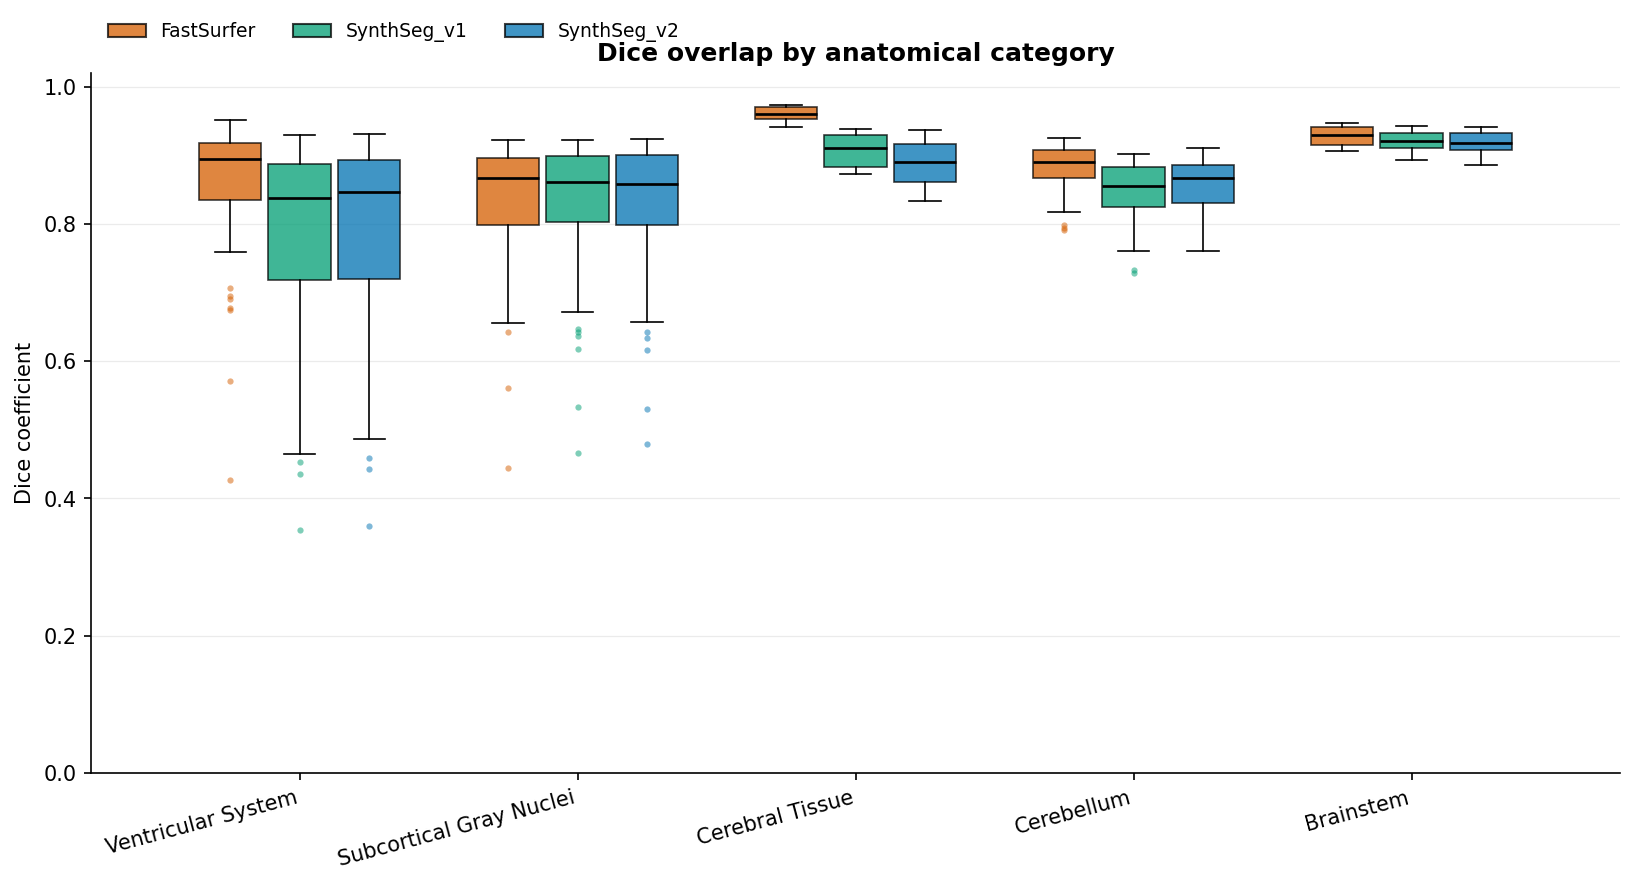

In [ ]:
# ---------------- Figure 1: grouped box plot by category (Dice) ----------------

def grouped_boxplot(df, value_col, group_col, group_order, ylabel, title, save_path,
                     ylim=None, figsize=(11, 6)):
    fig, ax = plt.subplots(figsize=figsize)
    n_models = len(MODEL_ORDER)
    width = 0.75 / n_models
    positions_base = np.arange(len(group_order))

    for i, model in enumerate(MODEL_ORDER):
        offset = (i - (n_models - 1) / 2) * width
        data = [df[(df[group_col] == g) & (df['model'] == model)][value_col].dropna().values
                for g in group_order]
        bp = ax.boxplot(data, positions=positions_base + offset, widths=width * 0.9,
                         patch_artist=True, showfliers=True,
                         flierprops=dict(marker='o', markersize=3, alpha=0.5,
                                          markerfacecolor=MODEL_COLORS[model], markeredgecolor='none'),
                         medianprops=dict(color='black', linewidth=1.3))
        for box in bp['boxes']:
            box.set_facecolor(MODEL_COLORS[model])
            box.set_alpha(0.75)
            box.set_edgecolor('black')
            box.set_linewidth(0.8)
        for whisker in bp['whiskers']:
            whisker.set_color('black'); whisker.set_linewidth(0.8)
        for cap in bp['caps']:
            cap.set_color('black'); cap.set_linewidth(0.8)

    ax.set_xticks(positions_base)
    ax.set_xticklabels(group_order, rotation=15, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=12, fontweight='bold')
    if ylim: ax.set_ylim(ylim)
    ax.grid(axis='y', alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    legend_handles = [Patch(facecolor=MODEL_COLORS[m], edgecolor='black', alpha=0.75, label=m)
                       for m in MODEL_ORDER]
    ax.legend(handles=legend_handles, loc='lower left', frameon=False, ncol=3,
              bbox_to_anchor=(0, 1.02), fontsize=9)
    plt.tight_layout()
    plt.savefig(save_path)
    plt.savefig(save_path.replace('.png', '.pdf'))
    plt.show()

grouped_boxplot(bilateral, 'dice', 'category', CATEGORY_ORDER,
                 ylabel='Dice coefficient', title='Dice overlap by anatomical category',
                 save_path=f"{OUT_DIR}/fig1_category_boxplot_dice.png", ylim=(0, 1.02))


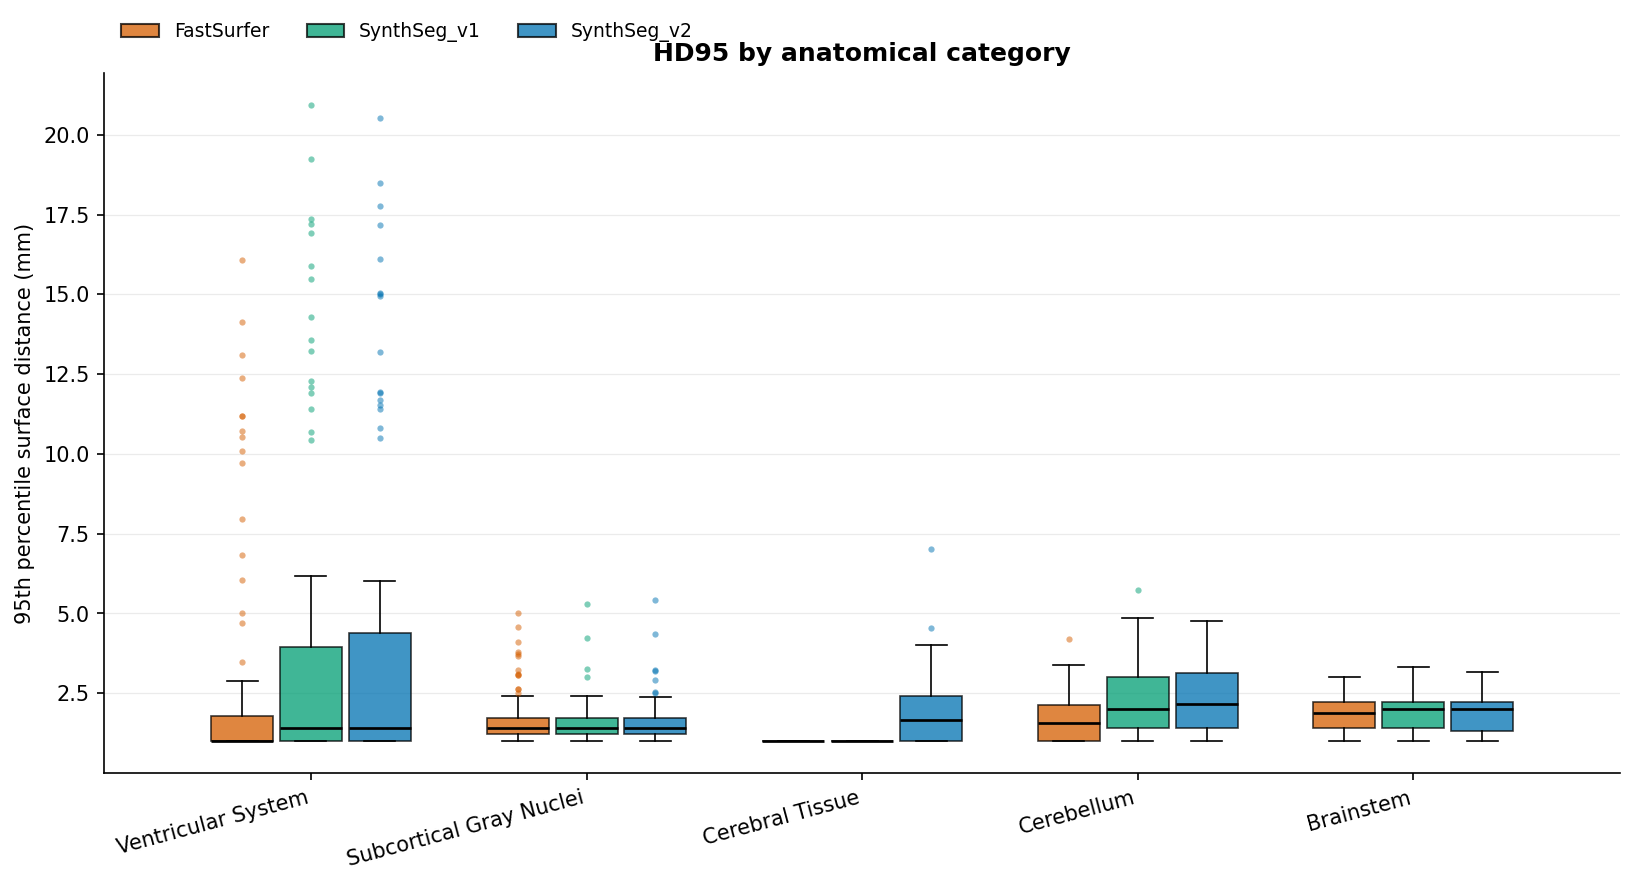

In [ ]:
# ---------------- Figure 1b: same layout for HD95 ----------------

grouped_boxplot(bilateral, 'hd95_mm', 'category', CATEGORY_ORDER,
                 ylabel='95th percentile surface distance (mm)',
                 title='HD95 by anatomical category',
                 save_path=f"{OUT_DIR}/fig1b_category_boxplot_hd95.png")


## Figure 2 — Sorted per-entity line chart

Mean Dice for each of the 17 entities (x-axis, sorted by category then alphabetically),
one connected line per model. This gives the full anatomical detail that the category
boxplot deliberately compresses.


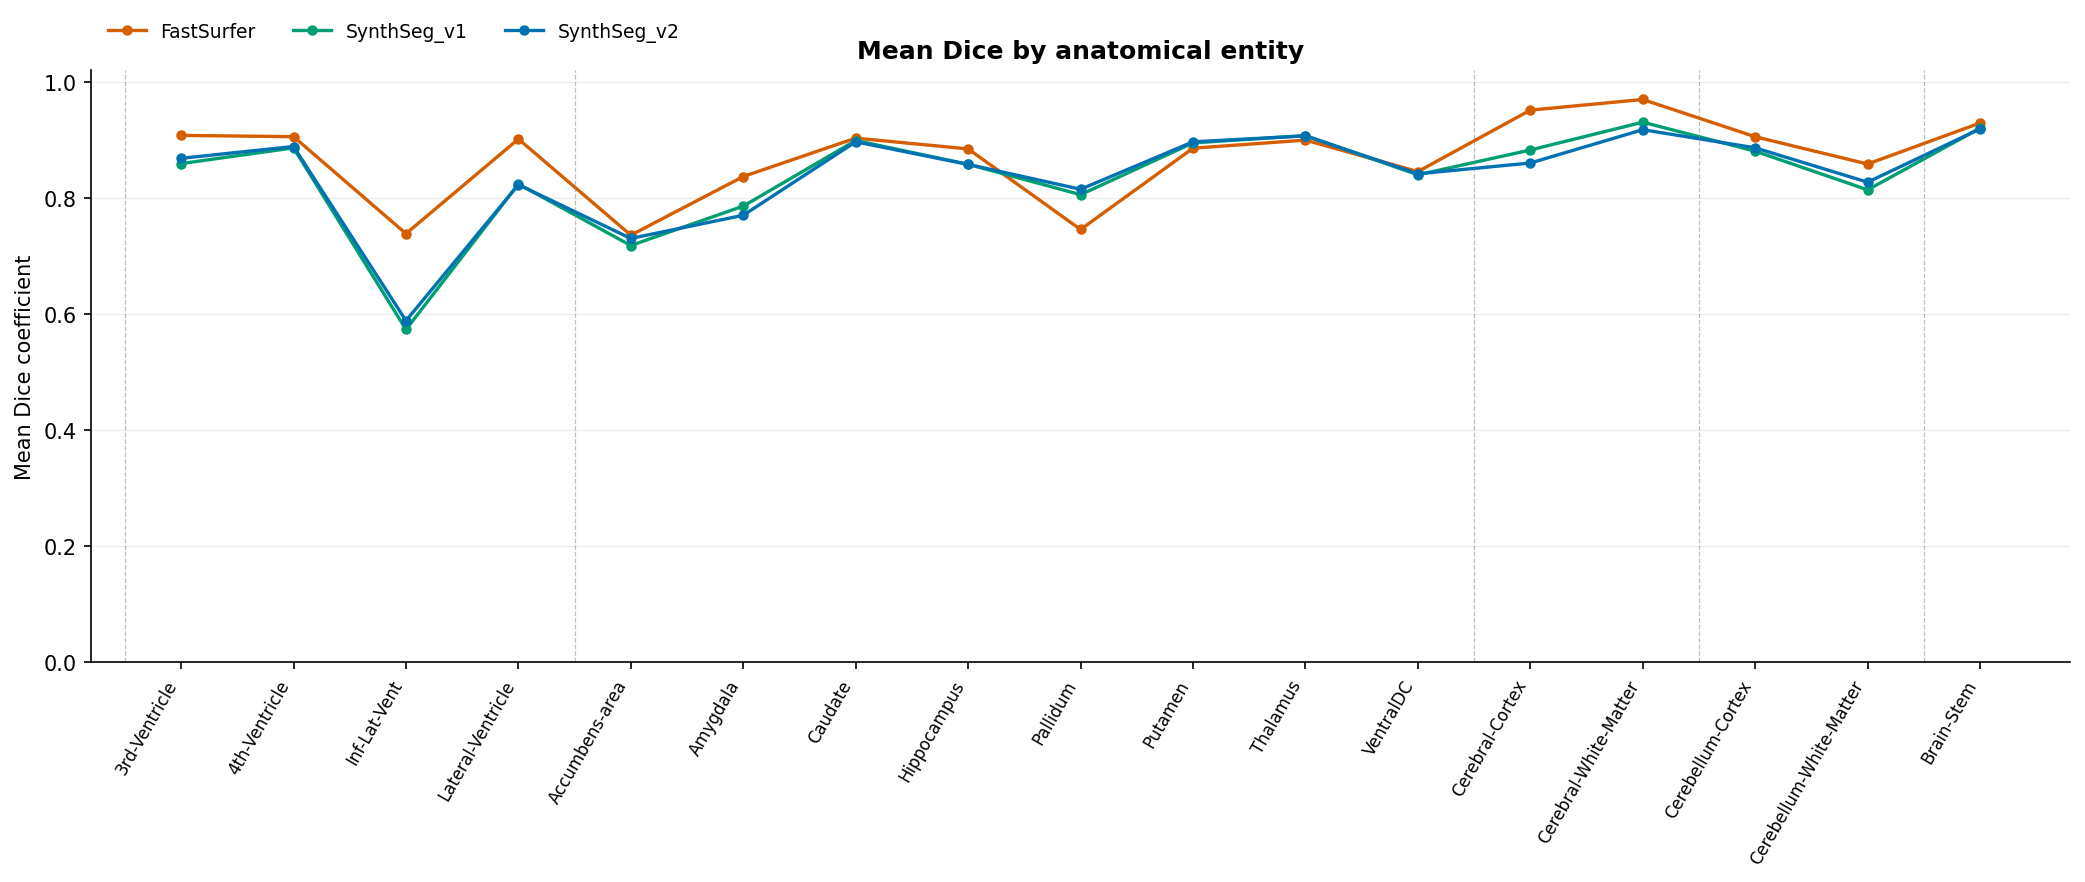

In [ ]:
# ---------------- Figure 2: sorted line chart, mean Dice per entity ----------------

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(ENTITY_ORDER))

for model in MODEL_ORDER:
    means = [bilateral[(bilateral['entity'] == e) & (bilateral['model'] == model)]['dice'].mean()
             for e in ENTITY_ORDER]
    ax.plot(x, means, marker='o', markersize=4, linewidth=1.6, color=MODEL_COLORS[model], label=model)

# Shade category boundaries for readability
prev_cat = None
for i, e in enumerate(ENTITY_ORDER):
    cat = CATEGORY_MAP[e]
    if cat != prev_cat:
        ax.axvline(i - 0.5, color='gray', linewidth=0.6, linestyle='--', alpha=0.5)
        prev_cat = cat

ax.set_xticks(x)
ax.set_xticklabels(ENTITY_ORDER, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Mean Dice coefficient')
ax.set_title('Mean Dice by anatomical entity', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.02)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc='lower left', frameon=False, ncol=3, bbox_to_anchor=(0, 1.02), fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig2_entity_line_dice.png")
plt.savefig(f"{OUT_DIR}/fig2_entity_line_dice.pdf")
plt.show()


## Figure 3 — Professional grouped bar chart

Category-level mean Dice as a grouped bar chart with error bars (SEM), matching the
clean grouped-bar-with-error-bar style of SynthMorph Fig. 12.


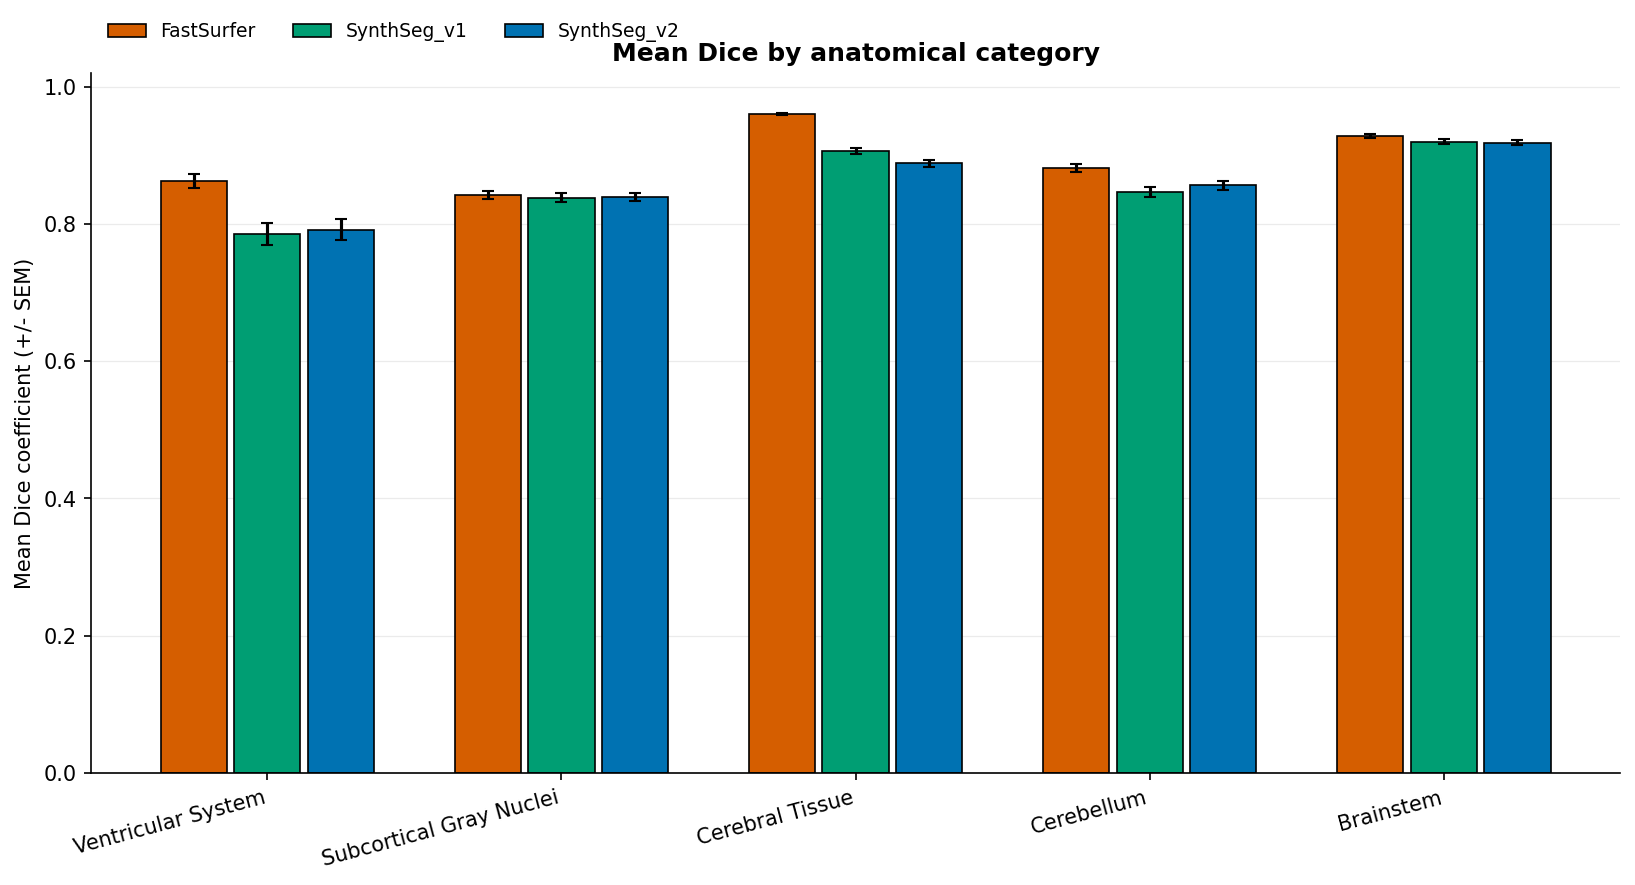

In [ ]:
# ---------------- Figure 3: grouped bar chart with error bars ----------------

fig, ax = plt.subplots(figsize=(11, 6))
n_models = len(MODEL_ORDER)
width = 0.75 / n_models
x = np.arange(len(CATEGORY_ORDER))

for i, model in enumerate(MODEL_ORDER):
    offset = (i - (n_models - 1) / 2) * width
    means, sems = [], []
    for cat in CATEGORY_ORDER:
        vals = bilateral[(bilateral['category'] == cat) & (bilateral['model'] == model)]['dice'].dropna()
        means.append(vals.mean())
        sems.append(vals.std() / np.sqrt(len(vals)) if len(vals) > 0 else 0)
    ax.bar(x + offset, means, width=width * 0.9, yerr=sems, capsize=3,
           color=MODEL_COLORS[model], edgecolor='black', linewidth=0.8, label=model)

ax.set_xticks(x)
ax.set_xticklabels(CATEGORY_ORDER, rotation=15, ha='right')
ax.set_ylabel('Mean Dice coefficient (+/- SEM)')
ax.set_title('Mean Dice by anatomical category', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.02)
ax.grid(axis='y', alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc='lower left', frameon=False, ncol=3, bbox_to_anchor=(0, 1.02), fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig3_category_bar_dice.png")
plt.savefig(f"{OUT_DIR}/fig3_category_bar_dice.pdf")
plt.show()


## Supplementary Figure S1 — Full entity-level box plot

All 17 entities individually, for readers who want complete structure-level detail rather
than the category-level summary in Figure 1.


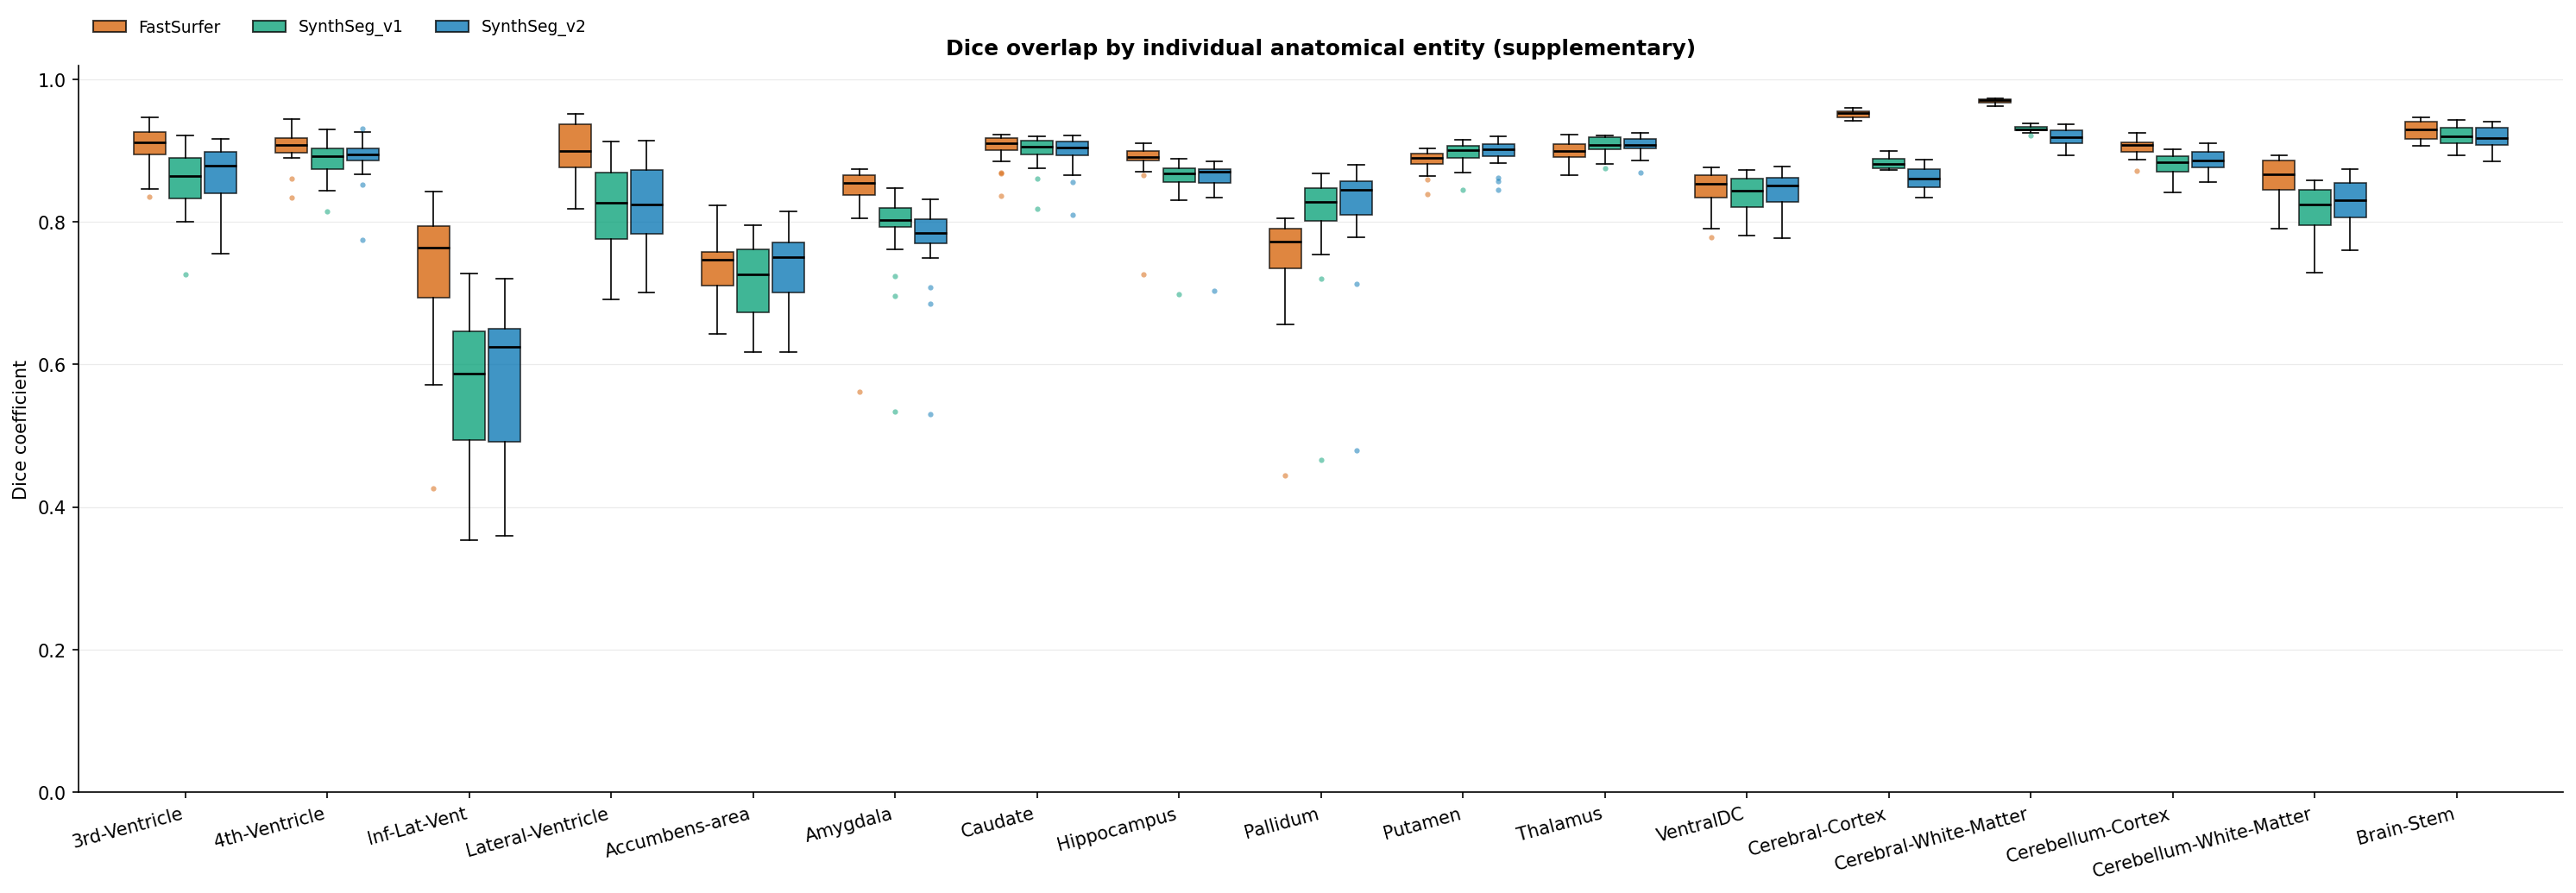

In [ ]:
# ---------------- Supplementary: full entity-level box plot ----------------

grouped_boxplot(bilateral, 'dice', 'entity', ENTITY_ORDER,
                 ylabel='Dice coefficient', title='Dice overlap by individual anatomical entity (supplementary)',
                 save_path=f"{OUT_DIR}/figS1_entity_boxplot_dice.png", ylim=(0, 1.02), figsize=(20, 7))


## Supplementary Figure S2 — Subject x entity Dice heatmap per model

Three heatmaps side by side (one per model), same color scale, for spotting subject-specific
or structure-specific failure patterns.


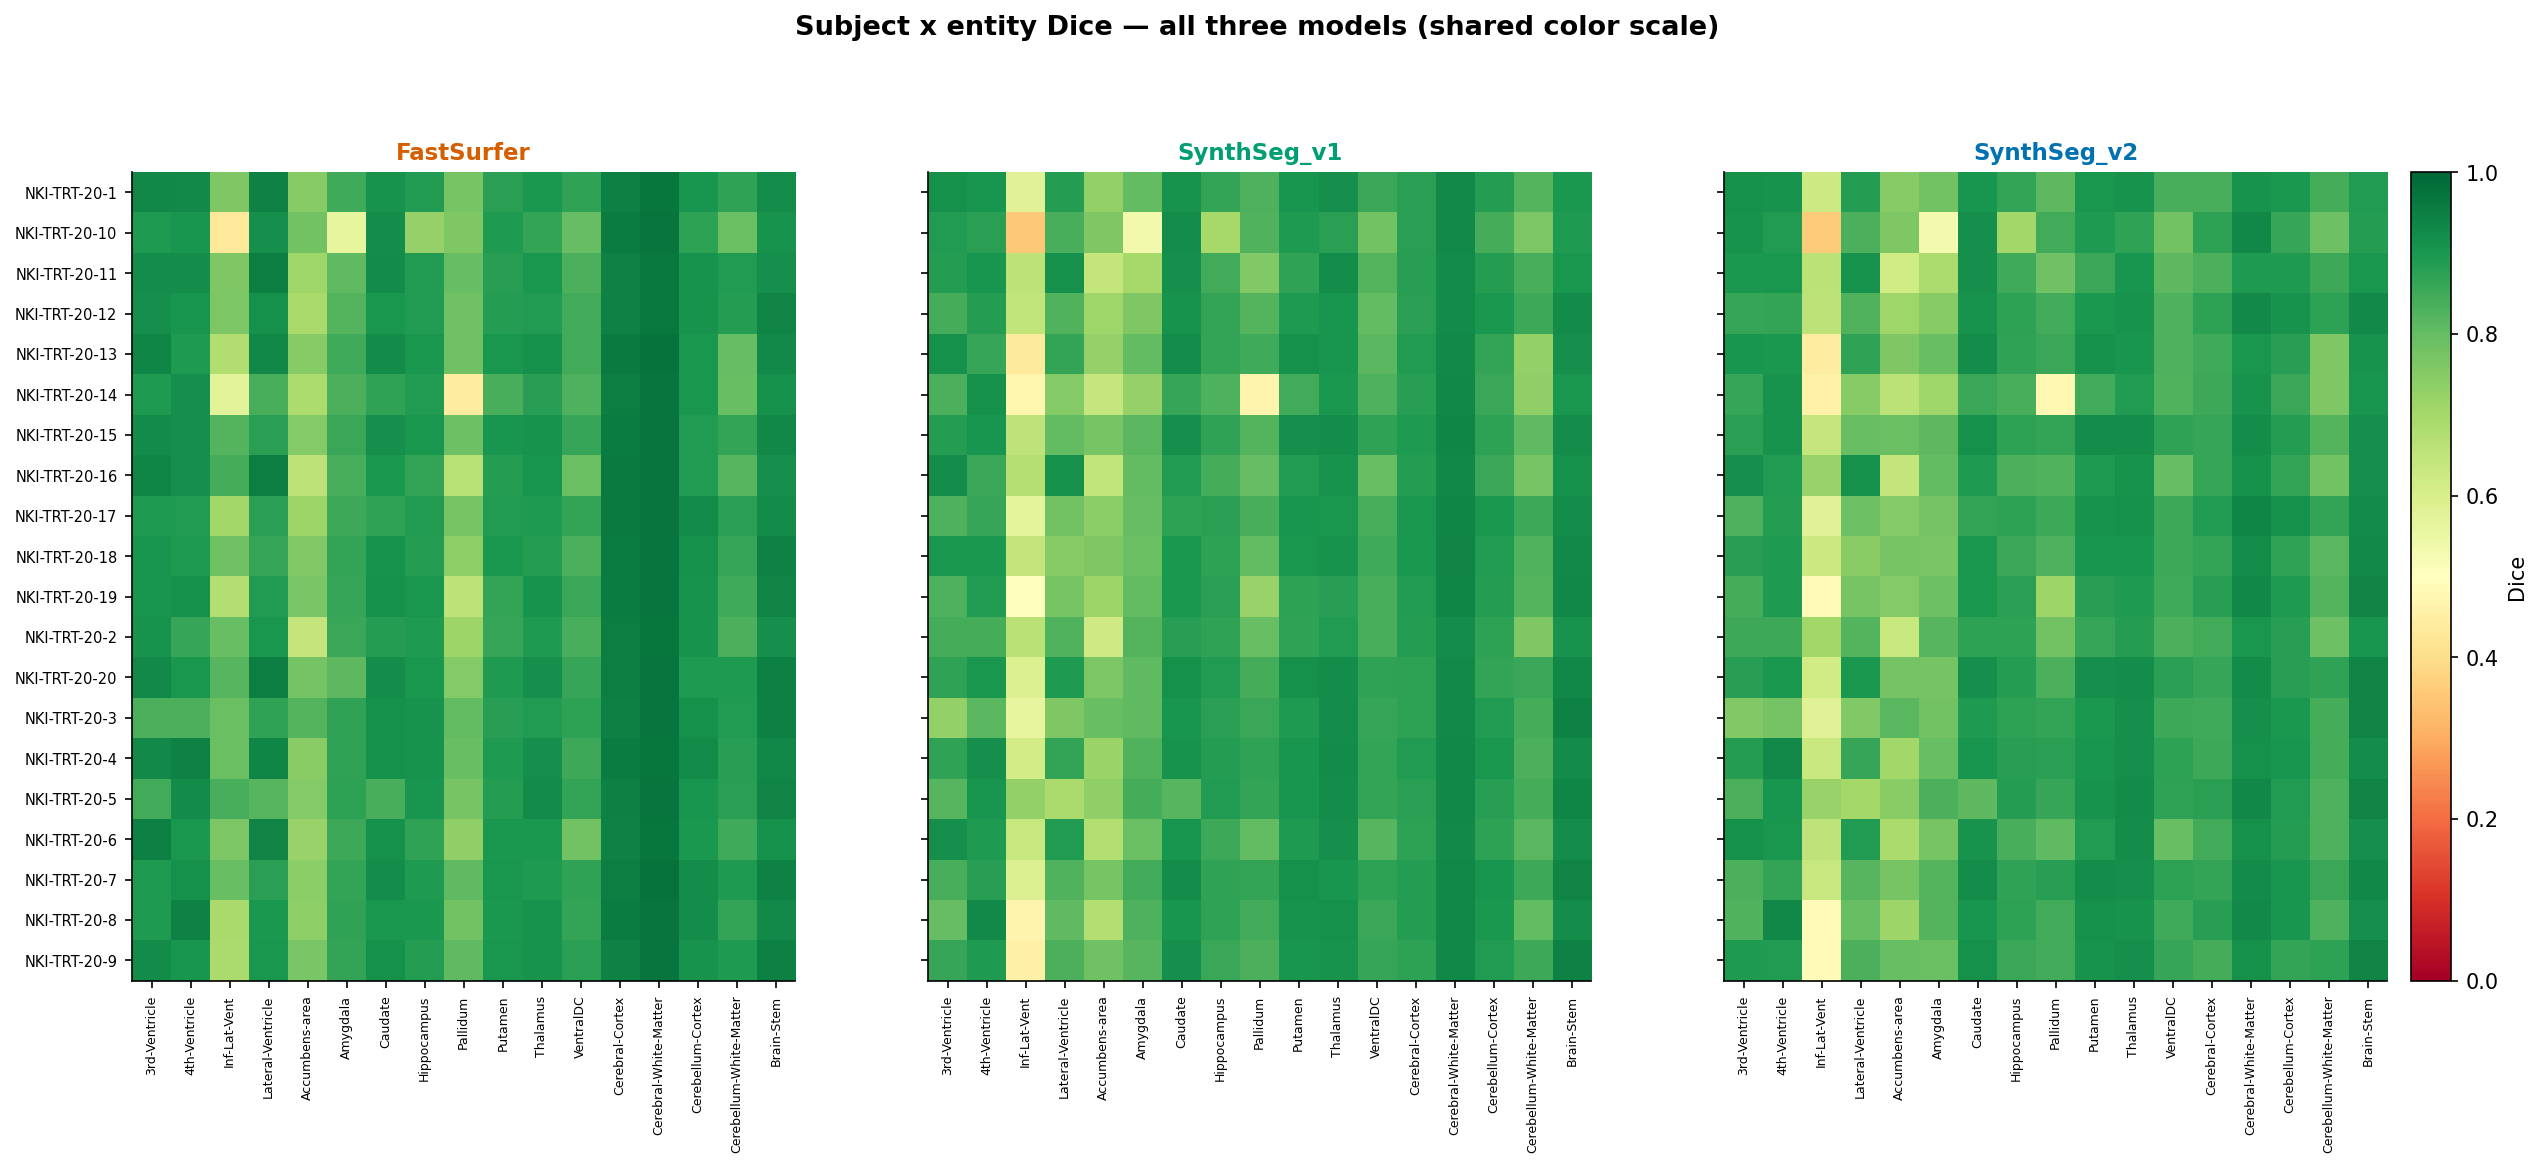

In [ ]:
# ---------------- Supplementary: subject x entity heatmaps ----------------

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
subjects_sorted = sorted(bilateral['subject'].unique())

for ax, model in zip(axes, MODEL_ORDER):
    sub = bilateral[bilateral['model'] == model]
    pivot = sub.pivot(index='subject', columns='entity', values='dice').reindex(
        index=subjects_sorted, columns=ENTITY_ORDER)
    im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(len(ENTITY_ORDER)))
    ax.set_xticklabels(ENTITY_ORDER, rotation=90, fontsize=6)
    ax.set_title(model, fontsize=11, fontweight='bold', color=MODEL_COLORS[model])
    if ax is axes[0]:
        ax.set_yticks(range(len(subjects_sorted)))
        ax.set_yticklabels(subjects_sorted, fontsize=7)

fig.colorbar(im, ax=axes, label='Dice', fraction=0.02, pad=0.01)
fig.suptitle('Subject x entity Dice — all three models (shared color scale)', fontsize=13, fontweight='bold', y=1.03)
plt.savefig(f"{OUT_DIR}/figS2_heatmap_all_models.png", bbox_inches='tight')
plt.show()


## Figure 4 — Qualitative comparison grid (SynthSeg Fig. 6 style)

Rows = representative subjects, columns = **T1 | Ground Truth | FastSurfer | SynthSeg v1 |
SynthSeg v2**, single column-title row at the top (not repeated per subject) — matching
SynthSeg Fig. 6's layout.

**Fill in the two missing paths below before running this cell** — this notebook only had
Drive paths for the SynthSeg v2 prediction folder; FastSurfer's and SynthSeg v1's prediction
folders (containing their `.nii.gz` outputs) weren't provided.


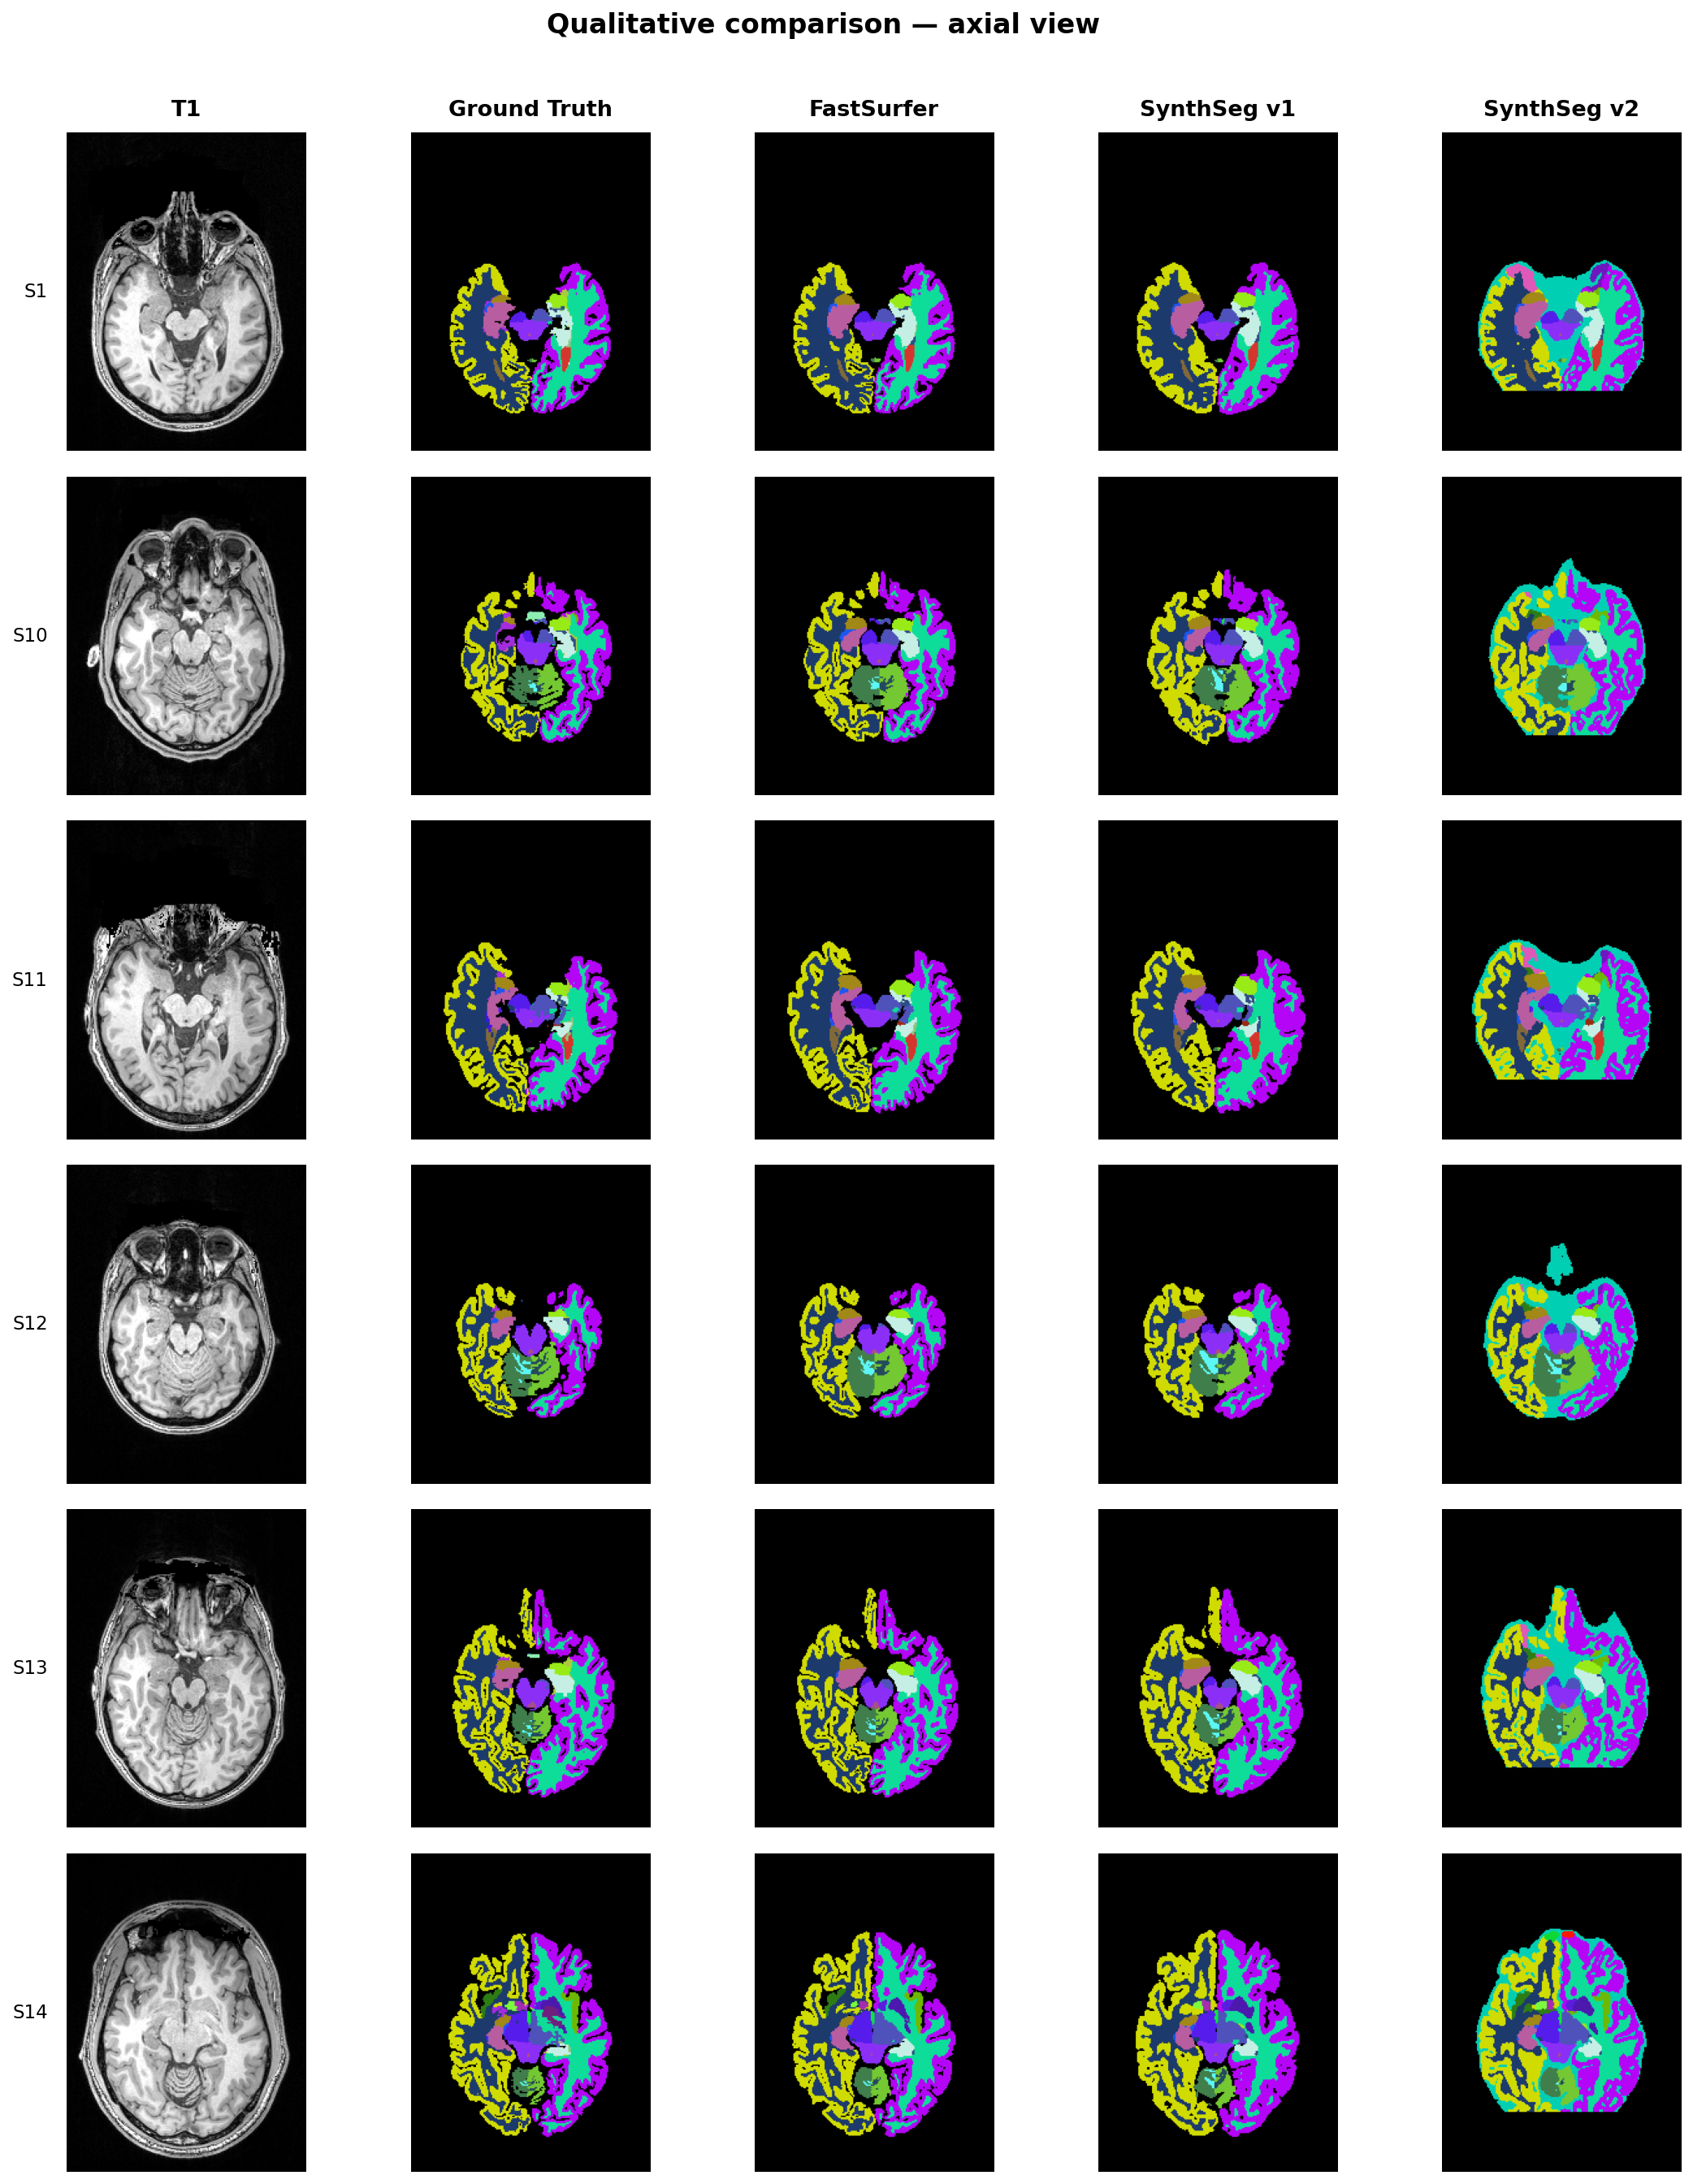

Saved qualitative grid to /content/drive/MyDrive/Registration/Comparison_SynthSeg_v1_v2_FastSurfer/fig4_qualitative_grid.png


In [ ]:
# ---------------- Figure 4: qualitative grid across all three models ----------------
# FILL IN THESE TWO PATHS:
FASTSURFER_PRED_DIR = "/content/drive/MyDrive/Registration/Mindboggle_FastSurfer/predictions"   # <-- confirm/fix
SYNTHSEG_V1_PRED_DIR = "/content/drive/MyDrive/Registration/Mindboggle_SynthSeg/predictions"     # <-- confirm/fix

GT_DIR = "/content/drive/MyDrive/Registration/Mindboggle_input/ground_truth"
T1_DIR = "/content/drive/MyDrive/Registration/Mindboggle_input/input_t1"
SYNTHSEG_V2_PRED_DIR = "/content/drive/MyDrive/Registration/SynthSeg_v2/prediction"

# Adjust these filename patterns to match each model's actual output naming
def fastsurfer_pred_path(subj):
    return f"{FASTSURFER_PRED_DIR}/{subj}_aparcDKTaseg.mgz"   # <-- confirm suffix

def synthseg_v1_pred_path(subj):
    return f"{SYNTHSEG_V1_PRED_DIR}/{subj}_T1_synthseg.nii.gz"  # <-- confirm suffix

def synthseg_v2_pred_path(subj):
    return f"{SYNTHSEG_V2_PRED_DIR}/{subj}_T1_synthseg.nii.gz"

MAX_LABEL = 2036
rng = np.random.RandomState(42)
LABEL_COLOR_LUT = rng.rand(MAX_LABEL + 1, 3)
LABEL_COLOR_LUT[0] = [0, 0, 0]

def labels_to_rgb(label_slice):
    return LABEL_COLOR_LUT[label_slice.astype(int)]

def normalize_gray_to_rgb(slice2d):
    lo, hi = np.percentile(slice2d, [1, 99])
    norm = np.clip((slice2d - lo) / (hi - lo + 1e-8), 0, 1)
    return np.stack([norm] * 3, axis=-1)

# Same DKT parcel ID ranges used in the SynthSeg v2 individual evaluation notebook
_dkt_ids_left = [i for i in range(1000, 1036) if i not in (1000, 1004, 1032, 1033, 1035)]
LEFT_CORTEX_IDS = _dkt_ids_left
RIGHT_CORTEX_IDS = [i + 1000 for i in _dkt_ids_left]

def load_labels_collapsed(path):
    """Load a label volume and collapse any DKT cortical parcel IDs (1002-1035 /
    2002-2035) down to combined Left/Right-Cerebral-Cortex (3/42), matching the
    32-structure convention used throughout the quantitative evaluation. Without
    this step, FastSurfer and SynthSeg v2 (both --parc-style outputs) show dozens
    of distinct cortical parcel colors while GT and SynthSeg v1 show one solid
    color, purely due to differing label IDs - not an actual color-mapping bug."""
    vol = np.asarray(nib.load(path).dataobj).astype(int)
    collapsed = vol.copy()
    collapsed[np.isin(vol, LEFT_CORTEX_IDS)] = 3
    collapsed[np.isin(vol, RIGHT_CORTEX_IDS)] = 42
    return collapsed

def get_mid_axial_slice(vol):
    return vol[:, :, vol.shape[2] // 2]

def load_t1(subj):
    return np.asarray(nib.load(f'{T1_DIR}/{subj}_T1.nii.gz').dataobj)

col_getters = [
    ('T1', lambda subj: normalize_gray_to_rgb(np.rot90(get_mid_axial_slice(load_t1(subj))))),
    ('Ground Truth', lambda subj: labels_to_rgb(np.rot90(get_mid_axial_slice(
        load_labels_collapsed(f'{GT_DIR}/{subj}_GT.nii.gz'))))),
    ('FastSurfer', lambda subj: labels_to_rgb(np.rot90(get_mid_axial_slice(
        load_labels_collapsed(fastsurfer_pred_path(subj)))))),
    ('SynthSeg v1', lambda subj: labels_to_rgb(np.rot90(get_mid_axial_slice(
        load_labels_collapsed(synthseg_v1_pred_path(subj)))))),
    ('SynthSeg v2', lambda subj: labels_to_rgb(np.rot90(get_mid_axial_slice(
        load_labels_collapsed(synthseg_v2_pred_path(subj)))))),
]

# ---------------- Publication-quality qualitative grid ----------------

N_SUBJECTS_TO_SHOW = 6
subjects = sorted(bilateral['subject'].unique())[:N_SUBJECTS_TO_SHOW]

# Load all images first
images = []

for subj in subjects:
    subject_images = [
        normalize_gray_to_rgb(
            np.rot90(get_mid_axial_slice(load_t1(subj)))
        ),

        labels_to_rgb(
            np.rot90(get_mid_axial_slice(
                load_labels_collapsed(f'{GT_DIR}/{subj}_GT.nii.gz')
            ))
        ),

        labels_to_rgb(
            np.rot90(get_mid_axial_slice(
                load_labels_collapsed(fastsurfer_pred_path(subj))
            ))
        ),

        labels_to_rgb(
            np.rot90(get_mid_axial_slice(
                load_labels_collapsed(synthseg_v1_pred_path(subj))
            ))
        ),

        labels_to_rgb(
            np.rot90(get_mid_axial_slice(
                load_labels_collapsed(synthseg_v2_pred_path(subj))
            ))
        )
    ]

    images.append(subject_images)


# ---------------- Plot ----------------

titles = [
    "T1",
    "Ground Truth",
    "FastSurfer",
    "SynthSeg v1",
    "SynthSeg v2"
]

n_rows = len(subjects)
n_cols = len(titles)

# Adjust these if you want larger/smaller panels
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 3.0 * n_rows),
    squeeze=False
)

for r in range(n_rows):
    for c in range(n_cols):

        ax = axes[r, c]

        # IMPORTANT: preserve the original image aspect ratio
        ax.imshow(images[r][c], aspect='equal')

        ax.axis('off')

        # Column titles
        if r == 0:
            ax.set_title(
                titles[c],
                fontsize=13,
                fontweight='bold',
                pad=10
            )

        # Subject labels
        if c == 0:
            ax.text(
                -0.08, 0.5,
                f"S{subjects[r].split('-')[-1]}",
                transform=ax.transAxes,
                ha='right',
                va='center',
                fontsize=11
            )


fig.suptitle(
    "Qualitative comparison — axial view",
    fontsize=16,
    fontweight='bold',
    y=0.995
)

plt.subplots_adjust(
    left=0.06,
    right=0.995,
    top=0.94,
    bottom=0.01,
    wspace=0.03,
    hspace=0.08
)

# Save
plt.savefig(
    f"{OUT_DIR}/fig4_qualitative_grid.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0.15
)

plt.savefig(
    f"{OUT_DIR}/fig4_qualitative_grid.pdf",
    bbox_inches='tight',
    pad_inches=0.15
)

plt.show()

print(f"Saved qualitative grid to {OUT_DIR}/fig4_qualitative_grid.png")

## Summary of saved outputs

All tables and figures from this notebook are saved to:

`/content/drive/MyDrive/Registration/Comparison_SynthSeg_v1_v2_FastSurfer/`

| File | Content |
|---|---|
| `table1_overall_summary.csv` | Table 1 — overall Dice/HD95/ASSD per model, bold best + significance |
| `table2a_category_dice.csv` | Category-level mean Dice |
| `table2b_entity_dice_supplementary.csv` | Full 17-entity mean +/- SD Dice |
| `fig1_category_boxplot_dice.png/.pdf` | Figure 1 — category grouped box plot (Dice) |
| `fig1b_category_boxplot_hd95.png` | Figure 1b — category grouped box plot (HD95) |
| `fig2_entity_line_dice.png/.pdf` | Figure 2 — sorted per-entity line chart |
| `fig3_category_bar_dice.png/.pdf` | Figure 3 — grouped bar chart with error bars |
| `figS1_entity_boxplot_dice.png` | Supplementary — full 17-entity box plot |
| `figS2_heatmap_all_models.png` | Supplementary — subject x entity heatmaps, all 3 models |
| `fig4_qualitative_grid.png/.pdf` | Figure 4 — qualitative T1/GT/3-model grid |
